
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [1]:
import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
import sys
sys.path.insert(0, "/mnt/data")


## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [2]:

# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 24
GRID_SIZE = 320
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=30,
    T_stop=0.5,
    n_steps=1000,
    nfreq=30,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1,
    min_substep_fraction=0.05,
    channel_divergence_threshold=1e4,
    eigenvalue_threshold=1e4,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
    diagnosis_Qs = [np.array([0.0, 0.0]), np.array([0.0,  np.pi/np.sqrt(3)]), np.array([ np.pi/2,  np.pi/(2*np.sqrt(3))]), np.array([-np.pi/2,  np.pi/(2*np.sqrt(3))])]
)


## 2. Build the standard spinful kagome model and the two spin patchsets

Patch counts: {'up': 21, 'dn': 21}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_21_dropDupM manual_exact_M_hex_21_dropDupM

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23]

===== up exact-M21 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=7.747470e-16 | w=[0. 1. 0.]
id= 1 | k=[-1.178097 -1.133625] | k_can=[1.963495 4.307773] | E=1.5265566589e-16 | |vF|=1.414214e+00 | w=[0.146447 0.853553 0.      ]
id= 2 | k=[-0.785398 -1.36035 ] | k_can=[2.356194 4.081049] | E=-3.6

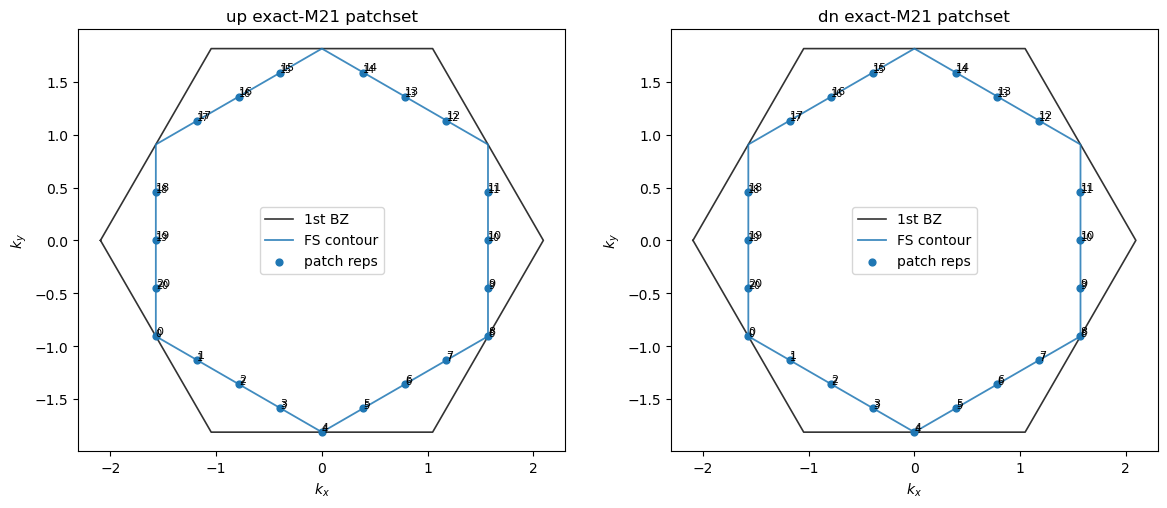

In [3]:
# ============================================================
# Manual exact-M patchsets on standard centered 1BZ hexagon
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)


# ------------------------------------------------------------
# reciprocal helpers (only for identifying duplicate M anchors)
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can


# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]


def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    # keep consistent cyclic order
    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]


def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # put points_per_edge points on each M-to-M segment:
        # t = 0, 1/p, 2/p, ..., (p-1)/p
        # exclude t=1 to avoid duplicating the next M point
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)


def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)


# ------------------------------------------------------------
# only remove duplicated M anchors from patch reps
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Important:
    - This function assumes the loop K_full is built exactly by exact_M_hex_loop_points.
    - Only the 6 M-anchor points are checked for modulo-G duplication:
          0, p, 2p, 3p, 4p, 5p
      where p = points_per_edge.
    - All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)


# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
):
    # 1) build the FULL standard loop exactly as in the original code
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # 2) only patch reps may be reduced; contour stays the original full loop
    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = _hex_bz_vertices_for_plot(model)

    patches = []
    for pid, k in enumerate(K_patch):
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix = "_dropDupM" if remove_duplicate_M_modG else ""
    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # <- keep original contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"manual_exact_M_hex_{npatch}{suffix}",
        gauge_loop_phase=0.0,
    )


# ------------------------------------------------------------
# choose patch density here
# ------------------------------------------------------------
POINTS_PER_EDGE = 4   # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
    ),
}

NPATCH = patchsets["up"].Npatch


# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )


# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))


# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour is now still the original full loop
        show_velocity=False,
        show_bz=True
    )
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)

    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

## 3. Helpers for running a benchmark interaction point  Debug FRG Solver

In [4]:
from frg_flow import FRGFlowSolver

_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}"
        )
        return rec
    except Exception as e:
        print(f"[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    # print("[DEBUG] temperature path:")
    # for i, T in enumerate(self.temperature_path):
    #     print(f"  i={i:03d}, T={float(T):.8f}")
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run

def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "leading_channel": rec.leading_channel_name,
            "leading_order": rec.leading_order_label,
            "leading_abs_eval": rec.leading_eigenvalue_abs,
            "instability": rec.instability,
            "reason": rec.instability_reason,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    evals = [np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs for h in history]
    norms = [h.channel_norm for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(steps, evals, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("leading |eigenvalue|")
    axes[0].set_title(f"{title}: leading eigenvalue")

    axes[1].plot(steps, norms, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("channel norm")
    axes[1].set_title(f"{title}: channel norm")

    plt.tight_layout()
    plt.show()


def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")
    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )
    history = solver.run()
    print(f"history length = {len(history)}")
    print(f"instability record = {None if solver.instability_record is None else solver.instability_record.step_index}")
    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)
    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }



## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=6.0, V=0.0) =====
[DEBUG] entering step: T_old=30.00000000, dT=-1.22701675e-01
[DEBUG] leaving step: T_new=29.87729832, rhs_norm=0.09933547978504366, channel_norm=0.012188629805324503, accepted_substeps=1, max_rel_update=0.002031438300887417
[DEBUG] entering step: T_old=29.87729832, dT=-1.22199819e-01
[DEBUG] leaving step: T_new=29.75509851, rhs_norm=0.10054865398810467, channel_norm=0.024475657101782546, accepted_substeps=1, max_rel_update=0.0020478378827430074
[DEBUG] entering step: T_old=29.75509851, dT=-1.21700015e-01
[DEBUG] leaving step: T_new=29.63339849, rhs_norm=0.10178013379612963, channel_norm=0.0368623008811145, accepted_substeps=1, max_rel_update=0.0020644406298886597
[DEBUG] entering step: T_old=29.63339849, dT=-1.21202255e-01
[DEBUG] leaving step: T_new=29.51219624, rhs_norm=0.10303025853192807, channel_norm=0.04934980053241257, accepted_substeps=1, max_rel_update=0.0020812499418830124
[DEBUG] entering step: T_old=29.51219624, dT=-1.2

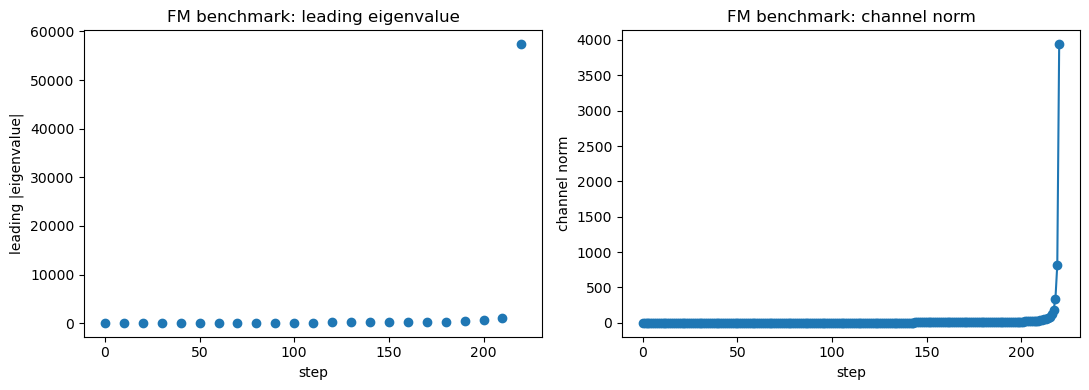

In [5]:

fm_result = run_case("FM benchmark", U=6.0, V=.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 10182.11
ph_mother_longitudinal   |eig|max = 57356.884
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 57356.884)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 5369.2375
ph_mother_longitudinal   |eig|max = 5429.9609
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 5429.9609)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 5207.4145
ph_mother_longitudinal   |eig|max = 5273.723
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 5273.723)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 6197.3888
ph_mother_longitudinal   |eig|max = 6604.6579
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 6604.6579)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 10182.110222

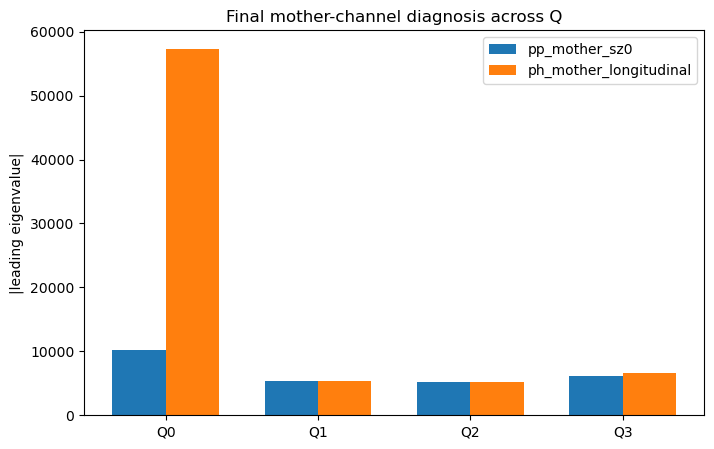


==== pp_mother_sz0 ====
Q = [0. 0.]
|eig|max = 10182.110222247182
vec.real = [-0.14273039 -0.21566647 -0.16253476 -0.15912567 -0.10091533 -0.14493269
 -0.14354457 -0.13998286 -0.12535046 -0.14025039 -0.14995633 -0.15890987
 -0.21566647 -0.16253476 -0.15912567 -0.14493269 -0.14354457 -0.13998286
 -0.14025039 -0.14995633 -0.15890987  0.14273039  0.21566647  0.16253476
  0.15912567  0.10091533  0.14493269  0.14354457  0.13998286  0.12535046
  0.14025039  0.14995633  0.15890987  0.21566647  0.16253476  0.15912567
  0.14493269  0.14354457  0.13998286  0.14025039  0.14995633  0.15890987]
vec.abs  = [0.14273039 0.21566647 0.16253476 0.15912567 0.10091533 0.14493269
 0.14354457 0.13998286 0.12535046 0.14025039 0.14995633 0.15890987
 0.21566647 0.16253476 0.15912567 0.14493269 0.14354457 0.13998286
 0.14025039 0.14995633 0.15890987 0.14273039 0.21566647 0.16253476
 0.15912567 0.10091533 0.14493269 0.14354457 0.13998286 0.12535046
 0.14025039 0.14995633 0.15890987 0.21566647 0.16253476 0.159125

In [6]:
import numpy as np
import matplotlib.pyplot as plt

Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]
# 如果你想继续测试 Q -> Q+G 不变性，再手动加 reciprocal vector
# Qs_to_check = FLOW_KWARGS["diagnosis_Qs"] + 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0,2*np.pi/np.sqrt(3)])

solver = fm_result["solver"]

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = solver.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)
labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
Q = np.array([0.0, 0.0])
mothers = solver.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("second |eig|max =", abs(vals[1]))
    print("vec.real =", np.real(vecs[:, 1]))
    print("vec.abs  =", np.abs(vecs[:, 1]))


## 5. sBO benchmark: `U=0, V=4`



===== Running case: PI benchmark (U=0.0, V=4.0) =====
[DEBUG] entering step: T_old=30.00000000, dT=-1.22701675e-01
[DEBUG] leaving step: T_new=29.87729832, rhs_norm=0.8476627608323725, channel_norm=0.10400964100543574, accepted_substeps=1, max_rel_update=0.013001205125679467
[DEBUG] entering step: T_old=29.87729832, dT=-1.22199819e-01
[DEBUG] leaving step: T_new=29.75509851, rhs_norm=0.8748767015687587, channel_norm=0.2109194153966697, accepted_substeps=1, max_rel_update=0.013363721798904245
[DEBUG] entering step: T_old=29.75509851, dT=-1.21700015e-01
[DEBUG] leaving step: T_new=29.63339849, rhs_norm=0.9035904746702164, channel_norm=0.3208863894483688, accepted_substeps=1, max_rel_update=0.013745871756462384
[DEBUG] entering step: T_old=29.63339849, dT=-1.21202255e-01
[DEBUG] leaving step: T_new=29.51219624, rhs_norm=0.9339130746232298, channel_norm=0.43407875992161454, accepted_substeps=1, max_rel_update=0.014149046309155722
[DEBUG] entering step: T_old=29.51219624, dT=-1.20706531e-0

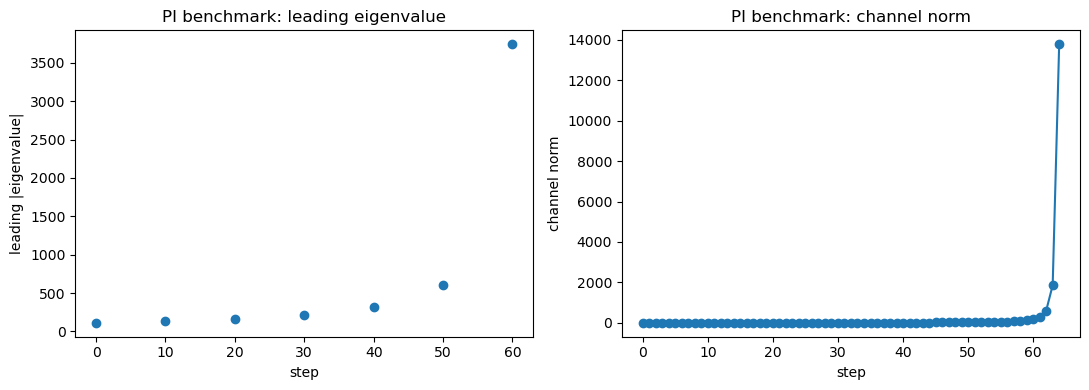

In [7]:

pi_result = run_case("PI benchmark", U=.0, V=4.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 26735.615
ph_mother_longitudinal   |eig|max = 279590
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 279590)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 26749.735
ph_mother_longitudinal   |eig|max = 26918.777
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 26918.777)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 26796.366
ph_mother_longitudinal   |eig|max = 26824.901
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 26824.901)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 26573.259
ph_mother_longitudinal   |eig|max = 26724.79
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 26724.79)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 26735.61511368379

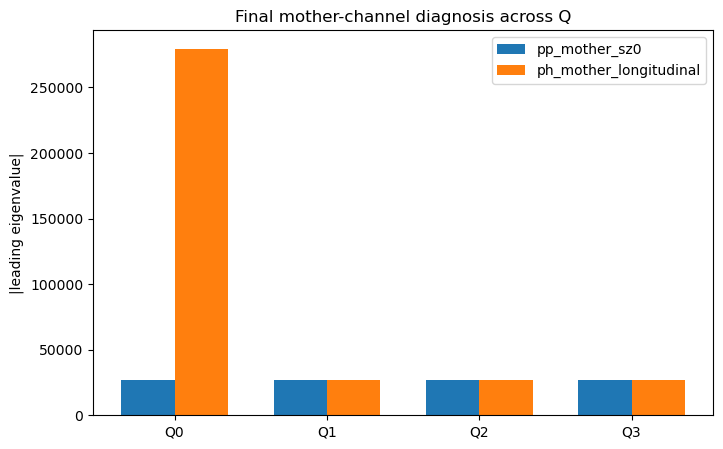


==== pp_mother_sz0 ====
Q = [0. 0.]
|eig|max = 26735.61511368379
vec.real = [ 4.20011891e-04 -5.46150669e-06  4.16136631e-04  7.60242494e-06
 -3.57886672e-07 -5.11847810e-06 -5.90895980e-05 -1.94900268e-06
  4.21255577e-04  3.87116520e-01  3.01727383e-03  3.16435771e-01
 -5.44181725e-06  4.16333228e-04  7.80076964e-06 -5.04893247e-06
 -5.94190388e-05 -1.87037639e-06  3.87108107e-01  3.02829917e-03
  3.16445151e-01 -4.20011891e-04  5.46150663e-06 -4.16136631e-04
 -7.60242497e-06  3.57886672e-07  5.11847812e-06  5.90895980e-05
  1.94900270e-06 -4.21255577e-04 -3.87116520e-01 -3.01727383e-03
 -3.16435771e-01  5.44181730e-06 -4.16333228e-04 -7.80076961e-06
  5.04893245e-06  5.94190388e-05  1.87037637e-06 -3.87108107e-01
 -3.02829917e-03 -3.16445151e-01]
vec.abs  = [4.20011891e-04 5.46150669e-06 4.16136631e-04 7.60242494e-06
 3.57886672e-07 5.11847810e-06 5.90895980e-05 1.94900268e-06
 4.21255577e-04 3.87116520e-01 3.01727383e-03 3.16435771e-01
 5.44181725e-06 4.16333228e-04 7.80076964e-06

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]
# 如果你想继续测试 Q -> Q+G 不变性，再手动加 reciprocal vector
# Qs_to_check = FLOW_KWARGS["diagnosis_Qs"] + 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0,2*np.pi/np.sqrt(3)])

solver = pi_result["solver"]

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = solver.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)
labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
Q = np.array([0.0, 0.0])
mothers = solver.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("second |eig|max =", abs(vals[1]))
    print("vec.real =", np.real(vecs[:, 1]))
    print("vec.abs  =", np.abs(vecs[:, 1]))

# Debug